In [ ]:
import numpy as np 
import scipy.stats as sts 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn 
from sklearn.linear_model import LinearRegression 
%matplotlib inline

# Гречишкин Денис ПМ-31

# Лабораторная работа  №12

# Часть 12.5 (Задания для самостоятельного выполнения)

# Вариант 7

## Задание 1: Осуществите статистическую обработку двумерной выборки по следующему плану. 
1)  Постройте диаграмму рассеивания и проанализируйте ее с точки зрения наличия и характера связи между компонентами выборочного вектора. Оправдано ли для описания зависимости использовать модель $Y = \beta_0 + \beta_1x + \beta_2x^2 + E$? Если вы считаете, что не оправдано, то для вы полнения следующих заданий используйте иную линейную регрессионную модель общего вида (но обязательно отличную от модели, рассмотренной в практической работе № 11). 
2)  Считая, что $M[Y | x] = \beta_0 + \beta_1x + \beta_2x^2$ найдите оценки параметров модели $y = \beta_0 + \beta_1x + \beta_2x^2$ (непосредственно по формулам, без использования специализированных функций языка программирования Python).
3)  Нанесите график построенного в п. 2 уравнения регрессии на диаграмму рассеивания. 

## Решение: импортируем данные

In [ ]:
DATA12 = pd.read_excel("Data_12_1.xlsx", header = 0)
D12 = pd.DataFrame(DATA12)
#D12 = D12.dropna()
D12 = D12.astype(float)
print(D12)
indexes = D12.keys()

X_MASSIV = D12[indexes[19]].dropna()
Y_MASSIV = D12[indexes[20]].dropna()
print('X_MASSIV\n', X_MASSIV)
print('Y_MASSIV\n', Y_MASSIV)

     Unnamed: 0  Вариант 1  Unnamed: 2  Unnamed: 3  Вариант 2  Unnamed: 5  \
0           NaN   8.692565  106.814293         NaN   8.061026   98.281853   
1           NaN   4.320720   37.051829         NaN   5.721574   51.868249   
2           NaN   4.961477   39.372434         NaN   5.365869   45.042234   
3           NaN   4.367834   20.675361         NaN   4.674800   41.973652   
4           NaN   3.446223   33.461613         NaN   8.981722  124.690960   
..          ...        ...         ...         ...        ...         ...   
105         NaN        NaN         NaN         NaN        NaN         NaN   
106         NaN        NaN         NaN         NaN        NaN         NaN   
107         NaN        NaN         NaN         NaN        NaN         NaN   
108         NaN        NaN         NaN         NaN        NaN         NaN   
109         NaN        NaN         NaN         NaN        NaN         NaN   

     Unnamed: 6  Вариант 3  Unnamed: 8  Unnamed: 9  ...  Unnamed: 56  \
0  

## Пункт 1

(-1.0, 10.0, -10.0, 200.0)

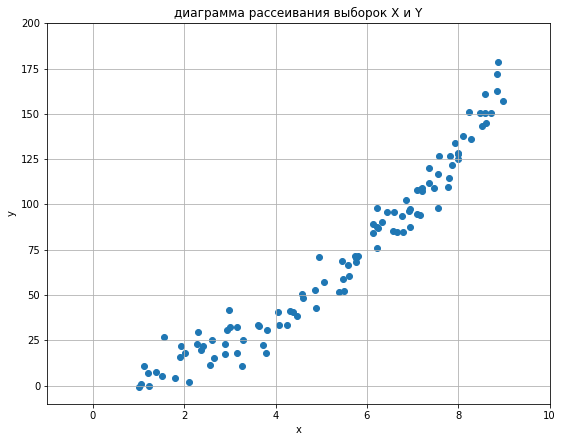

In [ ]:
plt.figure(figsize = (9, 7))
plt.scatter(X_MASSIV, Y_MASSIV)
plt.grid(True)
plt.title("диаграмма рассеивания выборок X и Y")
plt.xlabel('x')
plt.ylabel('y')
plt.axis([-1, 10, -10, 200])

Из графика можно предположение, что использование модели $Y = \beta_0 + \beta_1x + \beta_2x^2 + E$ - оправдано. Найдем оценки параметров $\beta_0; \beta_1; \beta_2$

## Пункт 2. Для того чтобы найти оценки $\beta_0; \beta_1; \beta_2$, необходимо решить систему уравнений: 
$$\begin{cases}
\beta_0n + \beta_1\sum x_i + \beta_2\sum x_i^2  = \sum y_i \\
\beta_0\sum x_i  + \beta_1\sum x_i^2  + \beta_2\sum x_i^3 = \sum x_iy_i \\
\beta_0\sum x_i^2 + \beta_1\sum x_i^3  + \beta_2\sum x_i^4  = \sum x_i^2y_i
\end{cases}
$$

Для того чтобы решить эту систему, сведем её к матричному виду:
$$A \cdot X = B$$
$$
\left(
\begin{matrix}
n & \sum x_i & \sum x_i^2 \\ 
\sum x_i & \sum x_i^2 & \sum x_i^3 \\
\sum x_i^2 & \sum x_i^3 & \sum x_i^4
\end{matrix}
\right)
\cdot
\left(
\begin{matrix}
\beta_0 \\ 
\beta_1 \\
\beta_2
\end{matrix}
\right)
=
\left(
\begin{matrix}
\sum y_i \\ 
\sum x_iy_i \\
\sum x_i^2y_i
\end{matrix}
\right)
$$
Решим её методом обратных матриц

In [ ]:
n = len(X_MASSIV)
sum_xi = 0
sum_xi_2 = 0
sum_xi_3 = 0
sum_xi_4 = 0
sum_yi = 0
sum_xi_yi = 0
sum_xi_2_yi = 0
for i in range(len(X_MASSIV)):
    sum_xi += X_MASSIV[i]
    sum_xi_2 += X_MASSIV[i]**2
    sum_xi_3 += X_MASSIV[i]**3
    sum_xi_4 += X_MASSIV[i]**4
    sum_yi += Y_MASSIV[i]
    sum_xi_yi += X_MASSIV[i]*Y_MASSIV[i]
    sum_xi_2_yi += X_MASSIV[i]**2*Y_MASSIV[i]
    
MATR_A = np.array([[n, sum_xi, sum_xi_2], [sum_xi, sum_xi_2, sum_xi_3], [sum_xi_2, sum_xi_3, sum_xi_4]])
MATR_B = np.array([[sum_yi], [sum_xi_yi], [sum_xi_2_yi]])
MATR_A_INV = np.linalg.inv(MATR_A)
MATR_X = MATR_A_INV.dot(MATR_B)
print("Решение системы X =")
MATR_X

Решение системы X =


array([[ 7.35046243],
       [-1.0557214 ],
       [ 2.06526019]])

In [ ]:
print("Найденные оценки:\n")
print("beta_0 =", MATR_X[0][0])
print("beta_1 =", MATR_X[1][0])
print("beta_2 =", MATR_X[2][0])

Найденные оценки:

beta_0 = 7.350462427197272
beta_1 = -1.0557213950676214
beta_2 = 2.065260191224354


## Пункт 3

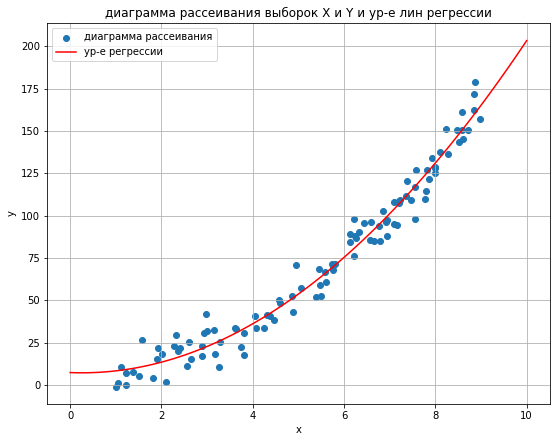

In [ ]:
plt.figure(figsize = (9, 7))
plt.scatter(X_MASSIV, Y_MASSIV, label = 'диаграмма рассеивания')
plt.grid(True)
plt.title("диаграмма рассеивания выборок X и Y и ур-е лин регрессии")
plt.xlabel('x')
plt.ylabel('y')
#plt.axis([-1, 10, -10, 200])

x_l_r = np.linspace(0, 10, 100)
beta0 = MATR_X[0][0]
beta1 = MATR_X[1][0]
beta2 = MATR_X[2][0]

y_l_r = beta0 + beta1*x_l_r + beta2*x_l_r**2
plt.plot(x_l_r, y_l_r, '-r' ,label = 'ур-е регрессии')
plt.legend()

$\newline$

## Задание 2: В предположении, что ошибки наблюдений не коррелированы и имеют нормальное распределение $N(0, \sigma)$, оцените качество аппроксимации результатов наблюдения уравнением регрессии $y = \beta_0 + \beta_1x + \beta_2x^2$ 
1) проверьте значимость модели на уровне $\alpha = 0,05$; 
2) найдите точечные оценки дисперсии ошибок наблюдений и ковариационной матрицы; 
3)  определите доверительные интервалы для параметров модели и дисперсии ошибок наблюдений при уровне значимости $\alpha = 0,05$.

## Решение:

## Пункт 1: Для проверки гипотезы: 
$$H_0: \beta_0 = 0; \beta_1 = 0, \beta_2 = 0$$
воспользуемся статистикой:
$$F = \frac{Q_R/(k-1)}{Q_e / (n - k)}$$
Если гипотеза $H_0$ верна (т.е модель статистически незначима), то статистика $F$ имеет распределение Фишера с $k-1$ и $n-k$ степенями свободы

In [15]:
def funct_regr(x):
    return beta0 + beta1*x + beta2*x**2
alpha = 0.05
overline_Y = np.mean(Y_MASSIV)
n = len(X_MASSIV)
k = 3
Qe = 0

Y = np.transpose(Y_MASSIV)
A = []#составляем регрессионную матрицу
for i in range(len(X_MASSIV)):
    arr = [1, X_MASSIV[i], X_MASSIV[i]**2]
    A.append(arr)

Qr = (np.transpose(MATR_X)).dot((np.transpose(A)).dot(Y_MASSIV))
print(Qr)
Qr = Qr[0] - n*(np.mean(Y_MASSIV))**2
for i in range(len(X_MASSIV)):
    Qe += (Y_MASSIV[i] - funct_regr(X_MASSIV[i]))**2
#Qy = Qr + Qe
print('Qe =', Qe)
print('Qr =', Qr)
#print('Qy =', Qy)
print('n =', n)
print('k =', k)
F_sel = (Qr/(k - 1))/((Qe)/(n - k))
print('Выборочное значение статистики F:', F_sel)
if(np.isclose(F_sel, (sts.f(k-1, n-k)).ppf(1-alpha))):
    print('Гипотеза о незначимости модели принимается')
    print(F_sel, '==', (sts.f(k-1, n-k)).ppf(1-alpha))
else:
    print('Гипотеза о незначимости модели отклоняется')
    print(F_sel, '!=', (sts.f(k-1, n-k)).ppf(1-alpha))

[791203.76856821]
Qe = 6502.5751143001435
Qr = 238627.91046685155
n = 106
k = 3
Выборочное значение статистики F: 1889.9185588824262
Гипотеза о незначимости модели отклоняется
1889.9185588824262 != 3.084576784880472


## Пункт 2: воспользуемся формулой точечной оценки дисперсии ошибок наблюдений:
$$s^2 = \frac{Q_e}{n - k}$$
и формулой оценки ковариацонной матрицы:
$$K = s^2(A_TA)^{-1}$$

In [16]:
S2 = Qe/(n-k)
K = S2 * np.linalg.inv((np.transpose(MATR_A)).dot(MATR_A))
print('Оценка дисперсии ошибок наблюдений', S2)
print('Оценка ковариационой матрицы:\n')
K

Оценка дисперсии ошибок наблюдений 63.131797226214985
Оценка ковариационой матрицы:



array([[ 3.72877571, -1.58475114,  0.14310683],
       [-1.58475114,  0.67524774, -0.06105571],
       [ 0.14310683, -0.06105571,  0.00552428]])

## Пункт 3: границы доверительных интервалов для $\beta_j$ будем считать по формулам:
$$\tilde{\beta_j} - t_{1-\alpha/2}(n-k)s\sqrt{a_{jj}} \lt \beta_j \lt \tilde{\beta_j} + t_{1-\alpha/2}(n-k)s\sqrt{a_{jj}}$$
где $a_{jj}$ - диагональный элемент матрицы $(A_TA)^{-1}$

In [17]:
alpha = 0.05
beta0 = MATR_X[0][0]
beta1 = MATR_X[1][0]
beta2 = MATR_X[2][0]

MATR_A = np.array([[n, sum_xi, sum_xi_2], [sum_xi, sum_xi_2, sum_xi_3], [sum_xi_2, sum_xi_3, sum_xi_4]])
MATR_A_T = np.transpose(MATR_A)
MATR = np.linalg.inv(MATR_A_T.dot(MATR_A))

lev_granitsa_beta_0 = beta0 - ((sts.t(n-k)).ppf(1-alpha/2))*np.sqrt(S2)*np.sqrt(MATR[0][0])
prav_granitsa_beta_0 = beta0 + ((sts.t(n-k)).ppf(1-alpha/2))*np.sqrt(S2)*np.sqrt(MATR[0][0])

lev_granitsa_beta_1 = beta1 - ((sts.t(n-k)).ppf(1-alpha/2))*np.sqrt(S2)*np.sqrt(MATR[1][1])
prav_granitsa_beta_1 = beta1 + ((sts.t(n-k)).ppf(1-alpha/2))*np.sqrt(S2)*np.sqrt(MATR[1][1])

lev_granitsa_beta_2 = beta2 - ((sts.t(n-k)).ppf(1-alpha/2))*np.sqrt(S2)*np.sqrt(MATR[2][2])
prav_granitsa_beta_2 = beta2 + ((sts.t(n-k)).ppf(1-alpha/2))*np.sqrt(S2)*np.sqrt(MATR[2][2])

print("доверительный интервал для beta0:")
print(lev_granitsa_beta_0, "< beta_0 <", prav_granitsa_beta_0, '\n')
print("доверительный интервал для beta1:")
print(lev_granitsa_beta_1, "< beta_1 <", prav_granitsa_beta_1, '\n')
print("доверительный интервал для beta2:")
print(lev_granitsa_beta_2, "< beta_2 <", prav_granitsa_beta_2)

доверительный интервал для beta0:
3.52077180799375 < beta_0 < 11.180153046400793 

доверительный интервал для beta1:
-2.6854381466136727 < beta_1 < 0.5739953564784301 

доверительный интервал для beta2:
1.9178530635741002 < beta_2 < 2.2126673188746078


$\newline$

## Задание 3: Для изучения вопроса об адекватности построенной модели проанализируйте остатки (выборку значений случайных ошибок 
наблюдений):  
1)  постройте график остатков в зависимости от $x_j$, проанализуйте его;  
2)  постройте гистограмму и проверьте гипотезу о распределении ошибок наблюдений по нормальному закону. К каким выводам вы пришли? 

## Решение:

## Пункт 1: под остатками будем подразумевать разности:
$$\Delta_j = y[j] - \tilde{y[j]} = y[j] - [\beta_0 + \beta_1x[j] + \beta_2(x[j])^2]$$

Text(0, 0.5, 'y')

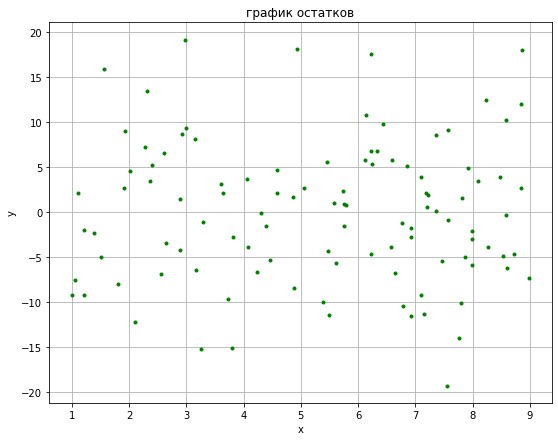

In [18]:
beta0 = MATR_X[0][0]
beta1 = MATR_X[1][0]
beta2 = MATR_X[2][0]

def funct_regr(x):
    return beta0 + beta1*x + beta2*x**2

ostatki = []
for i in range(len(X_MASSIV)):
    ostatki.append((Y_MASSIV[i] - funct_regr(X_MASSIV[i])))
plt.figure(figsize = (9, 7))
plt.plot(X_MASSIV, ostatki, '.g')
plt.grid(True)
plt.title("график остатков")
plt.xlabel('x')
plt.ylabel('y')
#plt.axis([-1, 1, -150, 150])

## Пункт 2: Проверку будем проводить используя критерий Шапиро-Уилка

Text(0, 0.5, 'y')

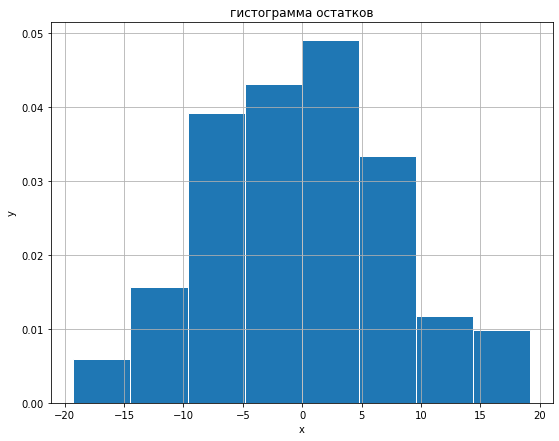

In [19]:
beta0 = MATR_X[0][0]
beta1 = MATR_X[1][0]
beta2 = MATR_X[2][0]

def funct_regr(x):
    return beta0 + beta1*x + beta2*x**2

ostatki = []
for i in range(len(X_MASSIV)):
    ostatki.append((Y_MASSIV[i] - funct_regr(X_MASSIV[i])))
plt.figure(figsize = (9, 7))
plt.hist(ostatki,  bins = 'sturges', edgecolor = 'white', density = True)
plt.grid(True)
plt.title("гистограмма остатков")
plt.xlabel('x')
plt.ylabel('y')
#plt.axis([-1, 1, -150, 150])

In [20]:
ostatki_check = sts.shapiro(ostatki)
print("РЕЗУЛЬТАТЫ ПРОВЕРКИ НА НОРМАЛЬНОСТЬ РАСПРЕДЕЛЕНИЯ ОСТАТКОВ")
print('Выборочное значение статистики:', ostatki_check.statistic)
print('Значение p-value:', ostatki_check.pvalue)

РЕЗУЛЬТАТЫ ПРОВЕРКИ НА НОРМАЛЬНОСТЬ РАСПРЕДЕЛЕНИЯ ОСТАТКОВ
Выборочное значение статистики: 0.9915183186531067
Значение p-value: 0.7531400918960571


Вывод: На уровне значимости $\alpha \lt 0.7531400918960571$ гипотеза о нормальном распределении статистики принимается

$\newline$

## Задание 4: Используйте для описания статистической зависимости компонент того же выборочного вектора модель 
$y = \beta_0 + \beta_1 x$. Сопоставьте характеристики построенной регрессионной модели с характеристиками регрессионной модели задания $y = \beta_0 + \beta_1 x + \beta_2 x^2$. Интерпретируйте результаты.

## Решение: находить коэффициенты моделей будем с помощью фукнции np.polyfit

In [21]:
lin_regression = np.polyfit(X_MASSIV, Y_MASSIV, 1)
beta0 = lin_regression[1]
beta1 = lin_regression[0]
print('КОЭФФИЦИЕНТЫ В МОДЕЛИ y = beta_0 + beta_1*x: \n')
print('beta_0 =', lin_regression[1])
print('beta_1 =', lin_regression[0], '\n')
#print(lin_regression)

def funct_lin_regr(x):
    return beta0 + beta1*x

n = len(X_MASSIV)
Qe = 0
for i in range(len(X_MASSIV)):
    Qe += (Y_MASSIV[i] - funct_lin_regr(X_MASSIV[i]))**2
print('Qe =', Qe)
print('n =', n)
S2 = Qe/(n-2)
print('Оценка дисперсии ошибок наблюдений s^2:', S2, '\n')
    


kvadr_regression = np.polyfit(X_MASSIV, Y_MASSIV, 2)
Beta0 = kvadr_regression[2]
Beta1 = kvadr_regression[1]
Beta2 = kvadr_regression[0]
print('КОЭФФИЦИЕНТЫ В МОДЕЛИ y = beta_0 + beta_1*x + beta_2*x^2: \n')
print('beta_0 =', kvadr_regression[2])
print('beta_1 =', kvadr_regression[1])
print('beta_2 =', kvadr_regression[0], '\n')

def funct_kvadr_regr(x):
    return Beta0 + Beta1*x + Beta2*x**2

n = len(X_MASSIV)
k = 3
Qe = 0
for i in range(len(X_MASSIV)):
    Qe += (Y_MASSIV[i] - funct_kvadr_regr(X_MASSIV[i]))**2
print('Qe =', Qe)
print('n =', n)
S_2 = Qe/(n-k)
print('Оценка дисперсии ошибок наблюдений s^2:', S_2)

КОЭФФИЦИЕНТЫ В МОДЕЛИ y = beta_0 + beta_1*x: 

beta_0 = -33.72007022459847
beta_1 = 19.79388420576776 

Qe = 16681.87814062719
n = 106
Оценка дисперсии ошибок наблюдений s^2: 160.40267442910758 

КОЭФФИЦИЕНТЫ В МОДЕЛИ y = beta_0 + beta_1*x + beta_2*x^2: 

beta_0 = 7.350462427198175
beta_1 = -1.0557213950685551
beta_2 = 2.06526019122445 

Qe = 6502.575114300145
n = 106
Оценка дисперсии ошибок наблюдений s^2: 63.131797226215


Вывод: видим что оценка дисперсии ошибок наблюдений во втором случае меньше, т.е лучше зависимость между x и y описывает модель $y = \beta_0 + \beta_1 x$